In [57]:
#importing libraries

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [58]:
#importing dataset into pandas dataframe

df = pd.read_csv('diabetes_nan.csv')

In [59]:
#prints total rows, column names, data type, non null count and memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome(target)           768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [60]:
#prints values for key statistics for numerical columns

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome(target)
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [61]:
#prints the first 10 rows of the dataset

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome(target)
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


In [62]:
#counts the numner of empty cells in eash column

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
outcome(target)               0
dtype: int64

In [63]:
#fill in the median values for each column into the empty cells

columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] 

for col in columns_to_clean:
   median = df[col].median()
   df[col] = df[col].fillna(median)


In [64]:
#prints total rows, column names, data type, non null count and memory usage
#confirms all all columns are complete
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome(target)           768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [65]:
#assigns feature columns to  x and target column to y

x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['outcome(target)']

In [66]:
# columns_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] 

# for col in columns_to_clean:
#     train_median = x_train[col].median()
#     x_train[col] = x_train[col].fillna(train_median)
#     x_test[col] = x_test[col].fillna(train_median)

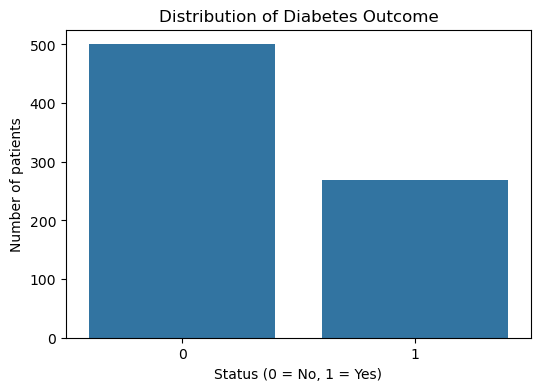

In [67]:
#plotting of a countplot for diabetes distribution

plt.figure(figsize = (6, 4))
sns.countplot(x = y)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Status (0 = No, 1 = Yes)')
plt.ylabel('Number of patients')
plt.show()

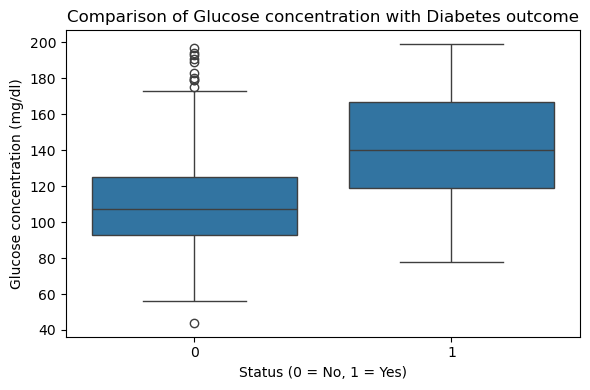

In [68]:
#plotting glucose concentration against diabetes outcome using a boxplot

plt.figure(figsize = (6,4))
sns.boxplot(x=y, y= x['Glucose'])
plt.title('Comparison of Glucose concentration with Diabetes outcome')
plt.xlabel('Status (0 = No, 1 = Yes)')
plt.ylabel('Glucose concentration (mg/dl)')
plt.tight_layout()
plt.show()

In [69]:
# plt.figure(figsize = (6,4))
# sns.boxplot(x=y_train, y= x_train['BMI'])
# plt.title('Comparison of Body Mass Index(BMI) with Diabetes outcome')
# plt.xlabel('Status (0 = No, 1 = Yes)')
# plt.ylabel('BMI')

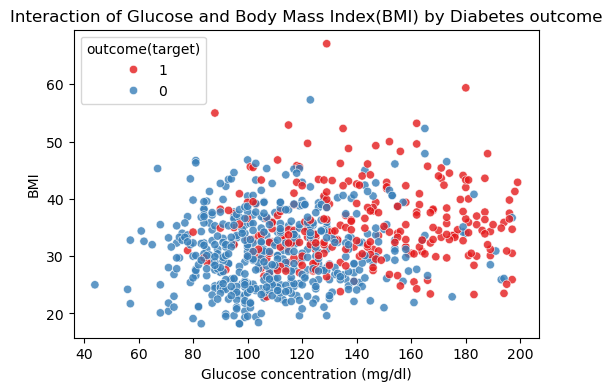

In [70]:
# a scatterplot showing the interaction of glucose and Body Mass Index(BMI) by Diabetes outcome

plt.figure(figsize = (6,4))
sns.scatterplot(x = x['Glucose'], y = x['BMI'], hue = y, hue_order = [1, 0], palette = 'Set1', alpha = 0.8)
plt.title('Interaction of Glucose and Body Mass Index(BMI) by Diabetes outcome')
plt.xlabel('Glucose concentration (mg/dl)')
plt.ylabel('BMI')
plt.show()

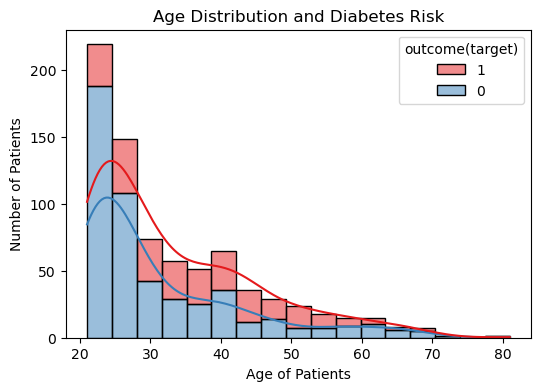

In [71]:
#A stacked histoplot of age distribution and diabetes outcome

plt.figure(figsize = (6,4))
sns.histplot(data = x, x = 'Age', hue = y, hue_order = [1, 0], palette = 'Set1', multiple = 'stack', kde = True,)
plt.title('Age Distribution and Diabetes Risk')
plt.xlabel('Age of Patients')
plt.ylabel('Number of Patients')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

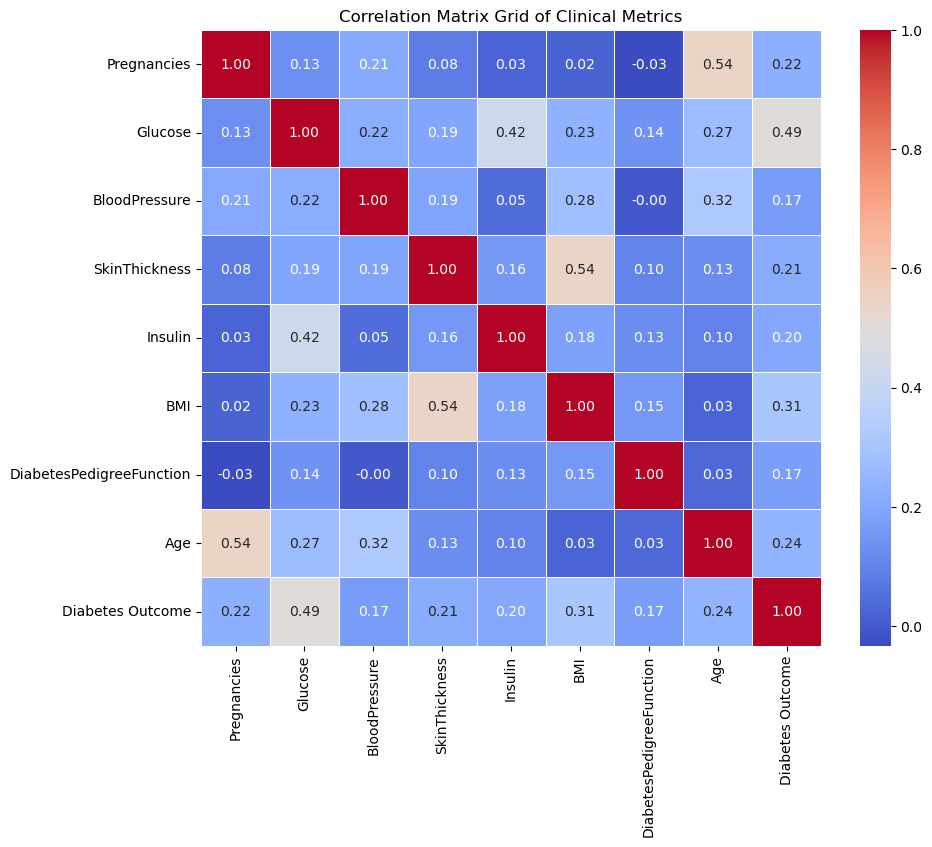

In [72]:
#a correlation map of all metrics

heatmap_data = x.copy()
heatmap_data['Diabetes Outcome'] = y
plt.figure(figsize = (10,8))
sns.heatmap(heatmap_data.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f', linewidth = 0.5)
plt.title('Correlation Matrix Grid of Clinical Metrics')
plt.show

In [73]:
#split data set into 80% training set and 20% test set

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =10, stratify = y)

In [74]:
x_train.info()
x_test.info()
print('-'*50)
y_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 332 to 709
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   614 non-null    float64
 2   BloodPressure             614 non-null    float64
 3   SkinThickness             614 non-null    float64
 4   Insulin                   614 non-null    float64
 5   BMI                       614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB
<class 'pandas.core.frame.DataFrame'>
Index: 154 entries, 194 to 623
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               154 non-null    int64  
 1   Glucose                   1

In [75]:
#scaling the dataset

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [76]:
# Set up the Hyperparameter Grid to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Testing different knob strengths
    'penalty': ['l2'],                     # Standard ridge penalty
    'solver': ['liblinear', 'lbfgs']       # Optimization algorithms
}

In [77]:
#Run Grid Search (Scoring based on 'recall' to focus on catching the sick patients)
grid_search = GridSearchCV(
    estimator=LogisticRegression(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='recall'
)
grid_search.fit(x_train_s, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='recall')

In [78]:
#Extract the optimized model
best_model = grid_search.best_estimator_
print("Best Settings Found:", grid_search.best_params_)


Best Settings Found: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [79]:
#testing the dataset using the testing set

predictions = best_model.predict(x_test_s)
accuracy = accuracy_score(y_test, predictions)
print(f"Prediction score: {accuracy * 100:.2f}%")

Prediction score: 79.22%


In [80]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       100
           1       0.71      0.69      0.70        54

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



In [81]:
print("Best Parameters:", grid_search.best_params_)
print("Optimized Recall Score:", grid_search.best_score_)

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Optimized Recall Score: 0.5890365448504984


In [82]:
#printing the weight of each feature column

weights = best_model.coef_[0]
weights

array([0.2265339 , 0.48152411, 0.04007271, 0.09293765, 0.08112237,
       0.25734702, 0.14913921, 0.14104018])

In [83]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Weight (Coefficient)' : weights
})
feature_importance = feature_importance.sort_values(by = 'Weight (Coefficient)', ascending = False)

In [84]:
feature_importance

,Feature,Weight (Coefficient)
1,Glucose,0.481524
5,BMI,0.257347
0,Pregnancies,0.226534
6,DiabetesPedigreeFunction,0.149139
7,Age,0.141040
3,SkinThickness,0.092938
4,Insulin,0.081122
2,BloodPressure,0.040073


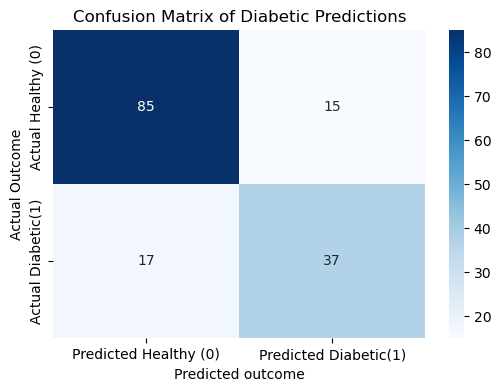

In [85]:
#printing the confusion matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
           xticklabels = ['Predicted Healthy (0)', 'Predicted Diabetic(1)'],
           yticklabels = ['Actual Healthy (0)', 'Actual Diabetic(1)'])
plt.title('Confusion Matrix of Diabetic Predictions')
plt.xlabel('Predicted outcome')
plt.ylabel('Actual Outcome')
plt.show()


In [86]:
joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']